# Polynomial Regression

In [38]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    SGDRegressor,
)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [5]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

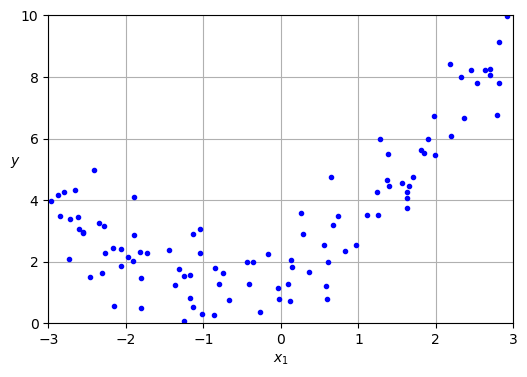

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.savefig("quadratic_data_plot")
plt.show()

In [10]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [11]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

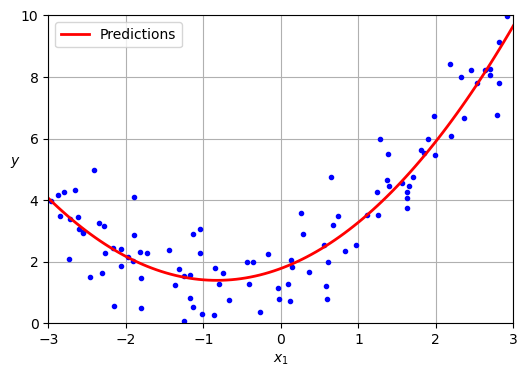

In [15]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.savefig("quadratic_predictions_plot")
plt.show()

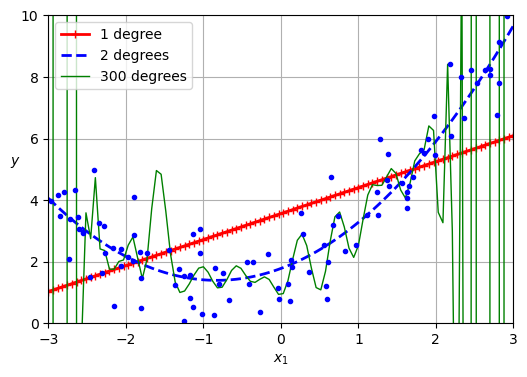

In [17]:
plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.savefig("high_degree_polynomials_plot")
plt.show()

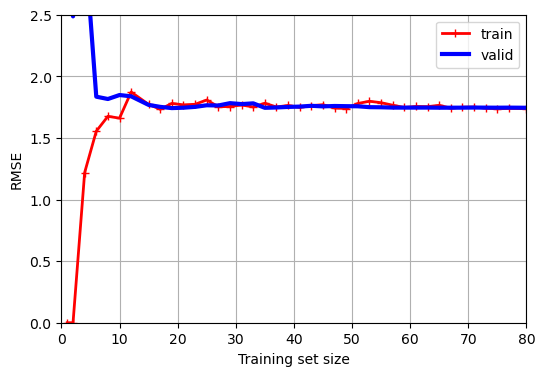

In [19]:
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.savefig("underfitting_learning_curves_plot")

plt.show()

In [20]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False), LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression,
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)

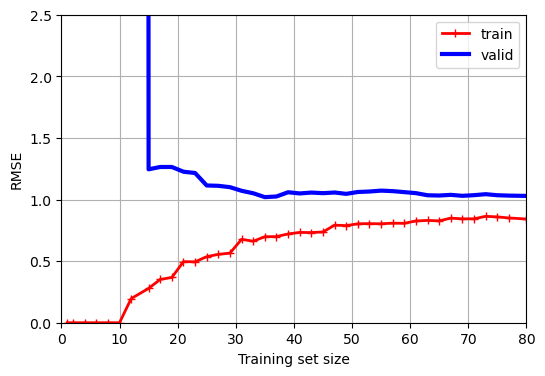

In [21]:
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
plt.savefig("learning_curves_plot")
plt.show()

# Regularized Linear Models
## Ridge Regression

In [22]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

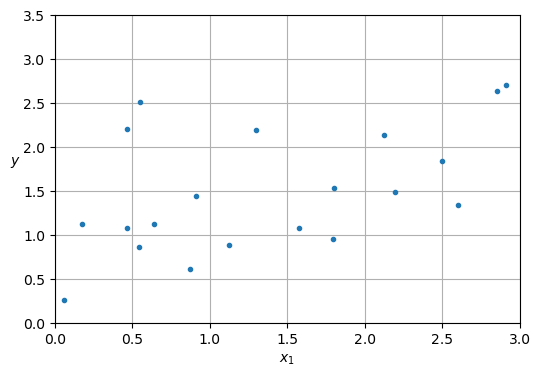

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [25]:
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55325833]])

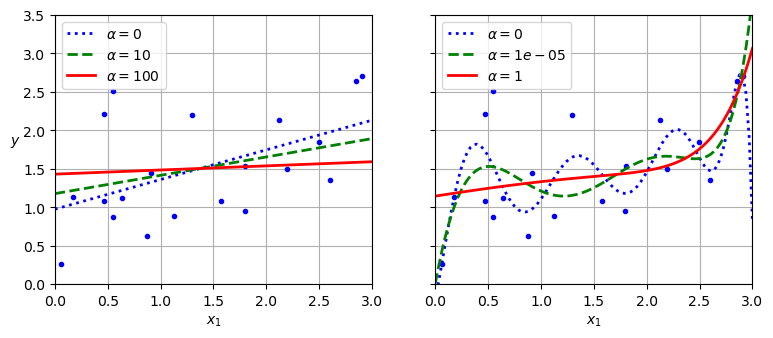

In [26]:
def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model,
            )
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2, label=rf"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()


plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.savefig("ridge_regression_plot")
plt.show()

In [28]:
sgd_reg = SGDRegressor(
    penalty="l2", alpha=0.1 / m, tol=None, max_iter=1000, eta0=0.01, random_state=42
)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

In [29]:
ridge_reg = Ridge(alpha=0.1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55326019]])

In [30]:
alpha = 0.1
A = np.array([[0.0, 0.0], [0.0, 1.0]])
X_b = np.c_[np.ones(m), X]
np.linalg.inv(X_b.T @ X_b + alpha * A) @ X_b.T @ y

array([[0.97898394],
       [0.3828496 ]])

In [31]:
ridge_reg.intercept_, ridge_reg.coef_

(array([0.97896386]), array([[0.38286422]]))

## Lasso Regression

In [33]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

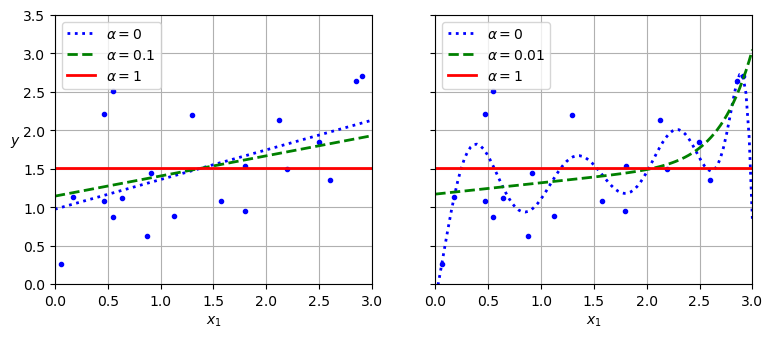

In [34]:
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.savefig("lasso_regression_plot")
plt.show()

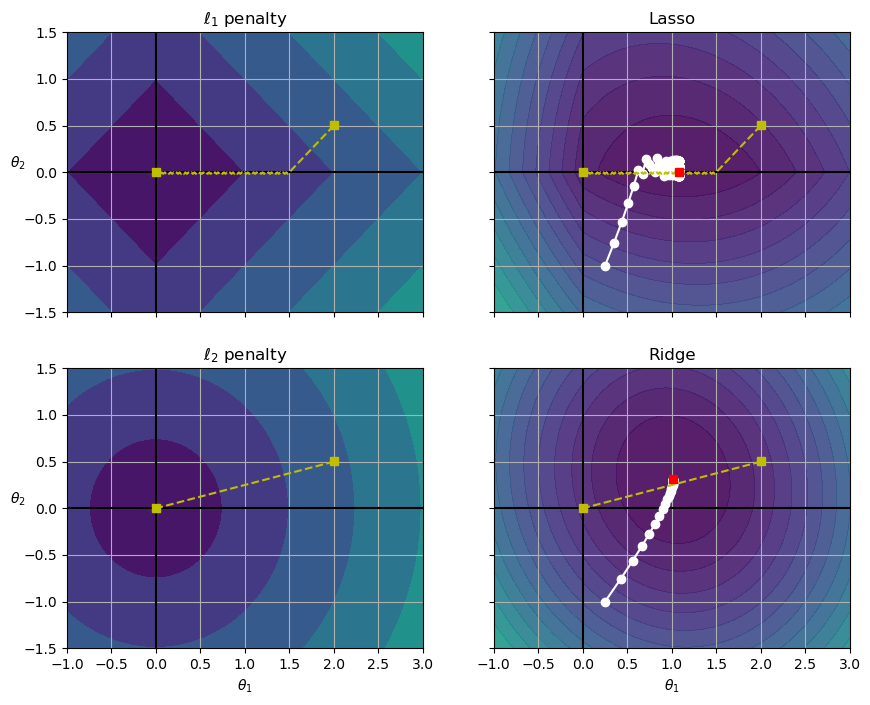

In [35]:
t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])


def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (
            core * 2 / len(X) * X.T @ (X @ theta - y) + l1 * np.sign(theta) + l2 * theta
        )
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2**2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(
        theta=np.array([[2.0], [0.5]]),
        X=Xr,
        y=yr,
        l1=np.sign(l1) / 3,
        l2=np.sign(l2),
        core=0,
    )
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(rf"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

plt.savefig("lasso_vs_ridge_plot")
plt.show()

## Elastic Net

In [37]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

## Early Stopping

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the func

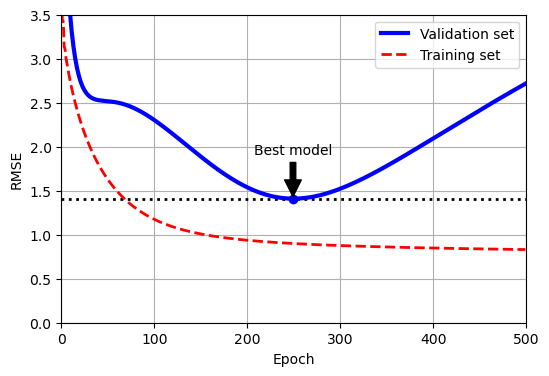

In [39]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(
    PolynomialFeatures(degree=90, include_bias=False), StandardScaler()
)
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float("inf")
train_errors, val_errors = [], []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = mean_squared_error(y_train, y_train_predict, squared=False)
    val_errors.append(val_error)
    train_errors.append(train_error)

best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate(
    "Best model",
    xy=(best_epoch, best_valid_rmse),
    xytext=(best_epoch, best_valid_rmse + 0.5),
    ha="center",
    arrowprops=dict(facecolor="black", shrink=0.05),
)
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
plt.savefig("early_stopping_plot")
plt.show()

# Обучение моделей
## 1.
- При наличии обучающего набора со многими миллионами признаков вы
можете применять стохастический градиентный спуск или мини-пакетный
градиентный спуск и возможно пакетный градиентный спуск, если
обучающий набор умещается в памяти. Но вы не можете использовать
нормальное уравнение, потому что с увеличением количества признаков
вычислительная сложность быстро растет (более чем квадратично).
## 2.
- Если признаки в вашем обучающем наборе имеют очень разные масштабы,
тогда функция издержек будет иметь форму вытянутой чаши,
поэтому алгоритмы градиентного спуска потребуют длительного времени
на схождение. Чтобы решить проблему, перед обучением модели вы
должны масштабировать данные. Обратите внимание, что нормальное
уравнение будет хорошо работать и без масштабирования. Кроме того,
если признаки не масштабированы, то регуляризированные модели
могут сходиться в субоптимальное решение: на самом деле, поскольку
регуляризация штрафует крупные веса, признаки с меньшими значениями
будут игнорироваться в сравнении с признаками, имеющими
более высокие значения.
## 3.
- Градиентный спуск не может застрять в локальном минимуме при обучении
логистической регрессионной модели, потому что функция издержек
является выпуклой.
## 4.
- Если задача оптимизации выпуклая (такая как линейная регрессия или
логистическая регрессия) и скорость обучения не очень высока, тогда
все алгоритмы градиентного спуска приведут в глобальный оптимум
и в итоге выработают довольно похожие модели. Тем не менее, если
только вы постепенно не снижаете скорость обучения, то стохастический
градиентный спуск и мини-пакетный градиентный спуск никогда
по-настоящему не сойдутся; взамен они продолжат прыжки вперед
и назад возле глобального оптимума. Это означает, что даже если вы
позволите им выполняться в течение очень долгого времени, упомянутые
алгоритмы градиентного спуска будут производить слегка отличающиеся
модели.
## 5.
- Если ошибка проверки последовательно растет после каждой эпохи,
то возможно причина в том, что скорость обучения слишком высока
и алгоритм расходится. Если ошибка обучения также увеличивается,
тогда это ясно указывает на проблему, и вы должны снизить скорость
обучения. Однако если ошибка обучения не растет, тогда модель переобучается
обучающим набором и вы должны остановить обучение.
## 6.
- Из-за своей случайной природы ни стохастический градиентный спуск,
ни мини-пакетный градиентный спуск не гарантируют продвижения
на каждой отдельно взятой итерации обучения. Следовательно, если
вы немедленно прекратите обучение, когда ошибка проверки возрастает,
то можете остановиться слишком рано, до достижения оптимума.
Более удачное решение предусматривает сохранение модели через регулярные
интервалы, и если она не улучшается в течение долгого времени
(это означает, что модель возможно никогда не побьет рекорд),
тогда вы можете возвратиться к наилучшей сохраненной модели.
## 7.
- Стохастический градиентный спуск имеет самую быструю итерацию
обучения, поскольку он рассматривает только один обучающий образец
за раз, так что в общем случае он первым достигнет окрестностей
глобального оптимума (или мини-пакетный градиентный спуск с очень
малым размером мини-пакета). Тем не менее, лишь пакетный градиентный
спуск действительно сойдется при условии достаточно долгого
времени обучения. Как упоминалось, если постепенно не снижать скорость
обучения, то стохастический градиентный спуск и мини-пакетный
градиентный спуск будут прыгать вокруг оптимума.
## 8.
- Если ошибка проверки намного превышает ошибку обучения, то причина,
скорее всего, в том, что ваша модель переобучается обучающим
набором. Одна попытка устранить проблему заключается в снижении
полиномиальной степени: модель с меньшим числом степеней свободы
менее склонна к переобучению. Другая попытка предусматривает регуляризацию
модели - скажем, путем добавления к функции издержек
штрафа L2 (гребневая регрессия) или штрафа L1 (лассо-регрессия) . Это
также сократит количество степеней свободы модели. Наконец, можно
попробовать увеличить размер обучающего набора.
## 9.
- Если ошибка обучения и ошибка проверки почти одинаковы и довольно
высоки, то модель, вероятно, недообучается на обучающем наборе,
что означает наличие у нее высокого смещения. Вы должны попробовать
снизить гиперпараметр регуляризации $а$.
## 10.
- Давайте посмотрим.
    - Модель с определенной регуляризацией обычно работает лучше, чем модель без регуляризации, поэтому в общем случае вы должны отдавать предпочтение гребневой регрессии перед обыкновенной линейной регрессией.
    - Лассо-регрессия применяет штраф L1 , который стремится довести веса до полных нулей. Итогом будут разреженные модели, где все веса за исключением наиболее важных являются нулевыми. Это способ автоматического выполнения выбора признаков, который хорош, если вы полагаете, что в действительности только немногие признаки существенны. Когда такой уверенности нет, вы должны использовать гребневую регрессию.
    - Эластичной сети обычно отдают предпочтение перед лассо-регрессией, т.к. в некоторых случаях лассо-регрессия может работать с перебоями (когда несколько признаков сильно связаны или признаков больше, чем обучающих образцов). Однако эластичная сеть добавляет дополнительный гиперпараметр, подлежащий подстройке. Если вы просто хотите получить лассо-регрессию, работающую без перебоев, тогда можете применять эластичную сеть со значением L1 _ rаtiо, близким к 1 .
